In [1]:
import os
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Scikit-Learn Core & Processing
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    cross_val_score,
    cross_validate,
    GridSearchCV,
    RandomizedSearchCV,
    learning_curve
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, RobustScaler
from sklearn.base import BaseEstimator, TransformerMixin

# Scikit-Learn Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

# Scikit-Learn Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve
)

# Global Seed & Configuration
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore")

# Plot Styling
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["font.size"] = 10
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 12

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Libraries successfully loaded!")
print("Global Reproducibility Seed set: RANDOM_STATE = 42")


Libraries successfully loaded!
Global Reproducibility Seed set: RANDOM_STATE = 42


In [2]:
DATA_PATH = Path("/Users/prem/MLPROJECTS/supervised_learning/Classifications/Employee/Employee.csv")



In [3]:
if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset path '{DATA_PATH}' not found.")

df_raw = pd.read_csv(DATA_PATH)

print(f"Dataset File: {DATA_PATH.resolve()}")
print(f"Dataset Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print("-" * 60)

# Check index column
index_cols = [col for col in ["Unnamed: 0", "index"] if col in df_raw.columns]
if index_cols:
    print(f"Removing accidental pandas index column(s): {index_cols}")
    df_raw = df_raw.drop(columns=index_cols)

print("First 5 Rows:")
display(df_raw.head(5))

print("\nLast 5 Rows:")
display(df_raw.tail(5))

print("\nDataset Info:")
df_raw.info()

Dataset File: /Users/prem/MLPROJECTS/supervised_learning/Classifications/Employee/Employee.csv
Dataset Shape: 4,653 rows x 9 columns
------------------------------------------------------------
First 5 Rows:


,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
0,Bachelors,2017,Bangalore,3,34,Male,No,0,0
1,Bachelors,2013,Pune,1,28,Female,No,3,1
2,Bachelors,2014,New Delhi,3,38,Female,No,2,0
3,Masters,2016,Bangalore,3,27,Male,No,5,1
4,Masters,2017,Pune,3,24,Male,Yes,2,1



Last 5 Rows:


,Education,JoiningYear,City,PaymentTier,Age,Gender,EverBenched,ExperienceInCurrentDomain,LeaveOrNot
4648,Bachelors,2013,Bangalore,3,26,Female,No,4,0
4649,Masters,2013,Pune,2,37,Male,No,2,1
4650,Masters,2018,New Delhi,3,27,Male,No,5,1
4651,Bachelors,2012,Bangalore,3,30,Male,Yes,2,0
4652,Bachelors,2015,Bangalore,3,33,Male,Yes,4,0



Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 4653 entries, 0 to 4652
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype
---  ------                     --------------  -----
 0   Education                  4653 non-null   str  
 1   JoiningYear                4653 non-null   int64
 2   City                       4653 non-null   str  
 3   PaymentTier                4653 non-null   int64
 4   Age                        4653 non-null   int64
 5   Gender                     4653 non-null   str  
 6   EverBenched                4653 non-null   str  
 7   ExperienceInCurrentDomain  4653 non-null   int64
 8   LeaveOrNot                 4653 non-null   int64
dtypes: int64(5), str(4)
memory usage: 327.3 KB


=== DATA AUDIT SUMMARY ===


,Data_Type,Missing_Count,Missing_Percentage,Unique_Values
Education,str,0,0.0000,3
JoiningYear,int64,0,0.0000,7
City,str,0,0.0000,3
PaymentTier,int64,0,0.0000,3
Age,int64,0,0.0000,20
Gender,str,0,0.0000,2
EverBenched,str,0,0.0000,2
ExperienceInCurrentDomain,int64,0,0.0000,8
LeaveOrNot,int64,0,0.0000,2


Exact Duplicate Rows Count: 1889

=== TARGET ('LeaveOrNot') DISTRIBUTION ===


,Count,Percentage (%)
LeaveOrNot,,
0,3053,65.6136
1,1600,34.3864


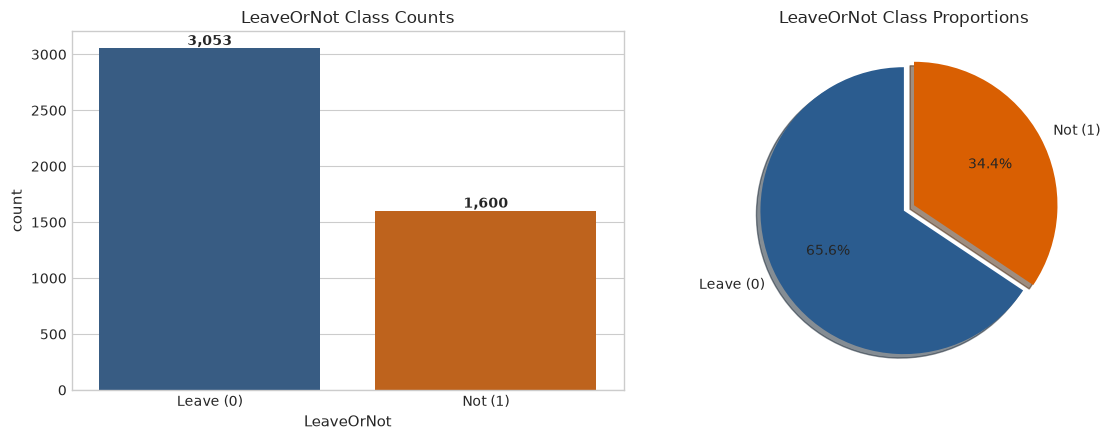

In [4]:
audit_df = pd.DataFrame({
    "Data_Type": df_raw.dtypes,
    "Missing_Count": df_raw.isnull().sum(),
    "Missing_Percentage": (df_raw.isnull().sum() / len(df_raw)) * 100,
    "Unique_Values": df_raw.nunique()
})

print("=== DATA AUDIT SUMMARY ===")
display(audit_df)

dup_count = df_raw.duplicated().sum()
print(f"Exact Duplicate Rows Count: {dup_count}")

# Target summary
t_counts = df_raw["LeaveOrNot"].value_counts()
t_pcts = df_raw["LeaveOrNot"].value_counts(normalize=True) * 100

t_summary = pd.DataFrame({"Count": t_counts, "Percentage (%)": t_pcts})
print("\n=== TARGET ('LeaveOrNot') DISTRIBUTION ===")
display(t_summary)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

sns.countplot(x="LeaveOrNot", data=df_raw, palette=["#2b5c8f", "#d95f02"], ax=ax[0])
ax[0].set_title("LeaveOrNot Class Counts")
ax[0].set_xticklabels(["Leave (0)", "Not (1)"])
for p in ax[0].patches:
    ax[0].annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontweight='bold')

ax[1].pie(t_counts, labels=["Leave (0)", "Not (1)"], autopct="%1.1f%%",
          colors=["#2b5c8f", "#d95f02"], startangle=90, explode=(0, 0.08), shadow=True)
ax[1].set_title("LeaveOrNot Class Proportions")

plt.tight_layout()
plt.show()


In [5]:
TARGET_COL = "LeaveOrNot"

print(f"Target Column: '{TARGET_COL}'")


# Separate Target y and Predictors X
y = df_raw[TARGET_COL].copy()
X_raw = df_raw.drop(columns=[TARGET_COL]).copy()

print(f"Predictor Matrix X Shape: {X_raw.shape}")
print(f"Target Vector y Shape: {y.shape}")

# Categorize columns
numerical_features = X_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_raw.select_dtypes(include=["object", "category"]).columns.tolist()

binary_numeric_features = [c for c in numerical_features if X_raw[c].nunique() == 2]
continuous_numerical_features = [c for c in numerical_features if c not in binary_numeric_features]

print("\n=== FEATURE TYPE BREAKDOWN ===")
print(f"Continuous Numerical ({len(continuous_numerical_features)}): {continuous_numerical_features}")
print(f"Binary Numerical ({len(binary_numeric_features)}): {binary_numeric_features}")
print(f"Categorical ({len(categorical_features)}): {categorical_features}")

Target Column: 'LeaveOrNot'
Predictor Matrix X Shape: (4653, 8)
Target Vector y Shape: (4653,)

=== FEATURE TYPE BREAKDOWN ===
Continuous Numerical (4): ['JoiningYear', 'PaymentTier', 'Age', 'ExperienceInCurrentDomain']
Binary Numerical (0): []
Categorical (4): ['Education', 'City', 'Gender', 'EverBenched']


In [6]:
X_clean = X_raw.copy()

for col in categorical_features:
    X_clean[col] = X_clean[col].astype(str).str.strip()

print("Cleaned whitespace from categorical columns.")
print("Unique category counts per feature:")
for col in categorical_features:
    print(f"  - {col}: {X_clean[col].unique().tolist()}")

# Numerical check
num_check = X_clean[numerical_features]
has_inf = np.isinf(num_check).sum().sum()

print(f"\nInfinite values count: {has_inf}")



Cleaned whitespace from categorical columns.
Unique category counts per feature:
  - Education: ['Bachelors', 'Masters', 'PHD']
  - City: ['Bangalore', 'Pune', 'New Delhi']
  - Gender: ['Male', 'Female']
  - EverBenched: ['No', 'Yes']

Infinite values count: 0


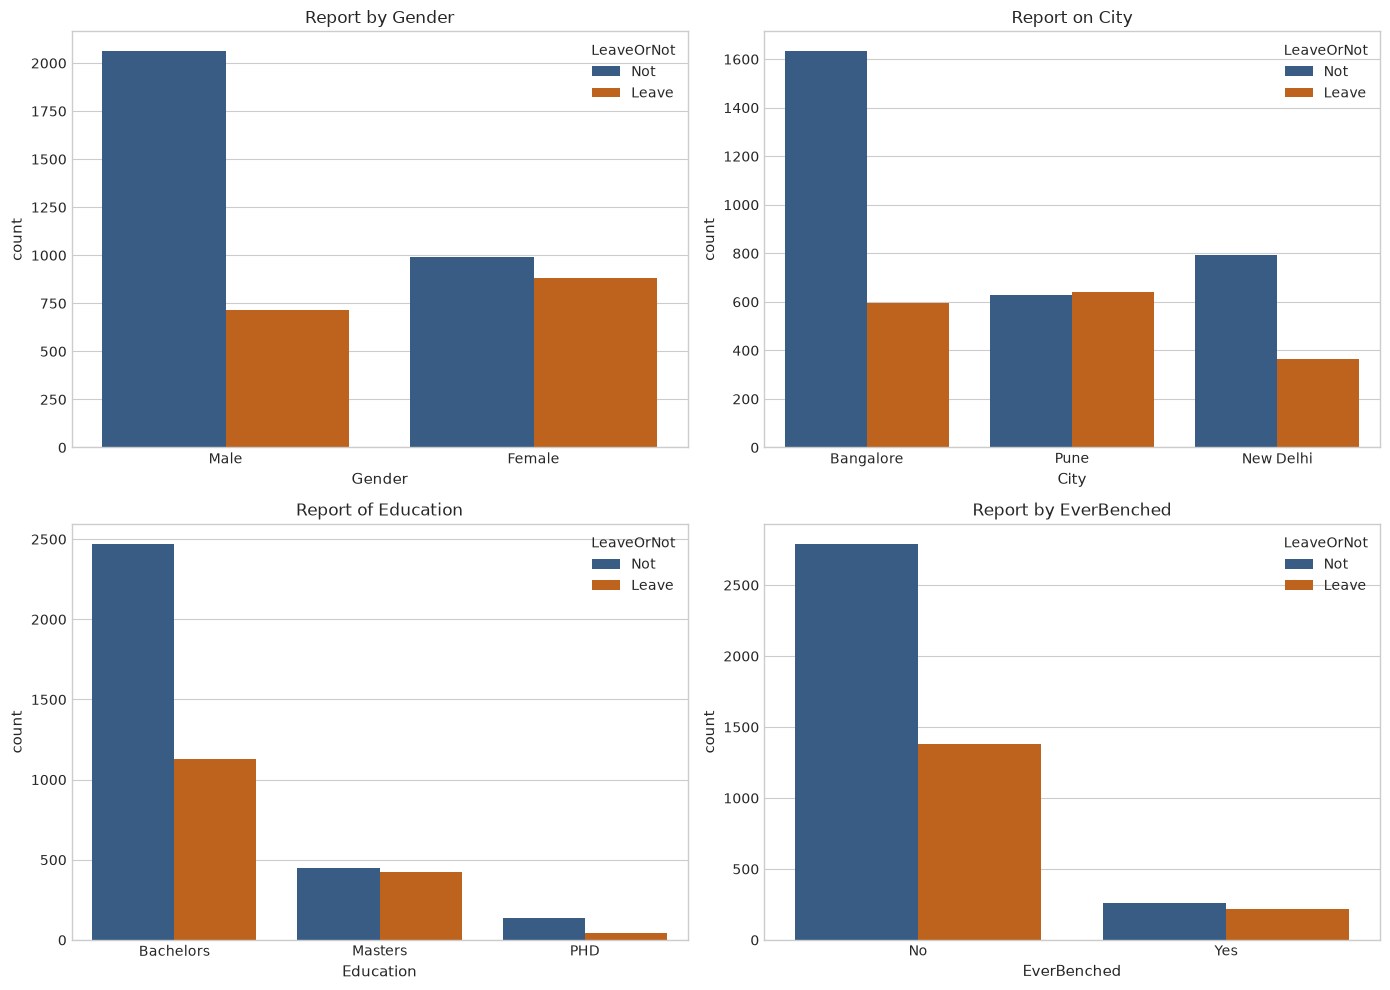

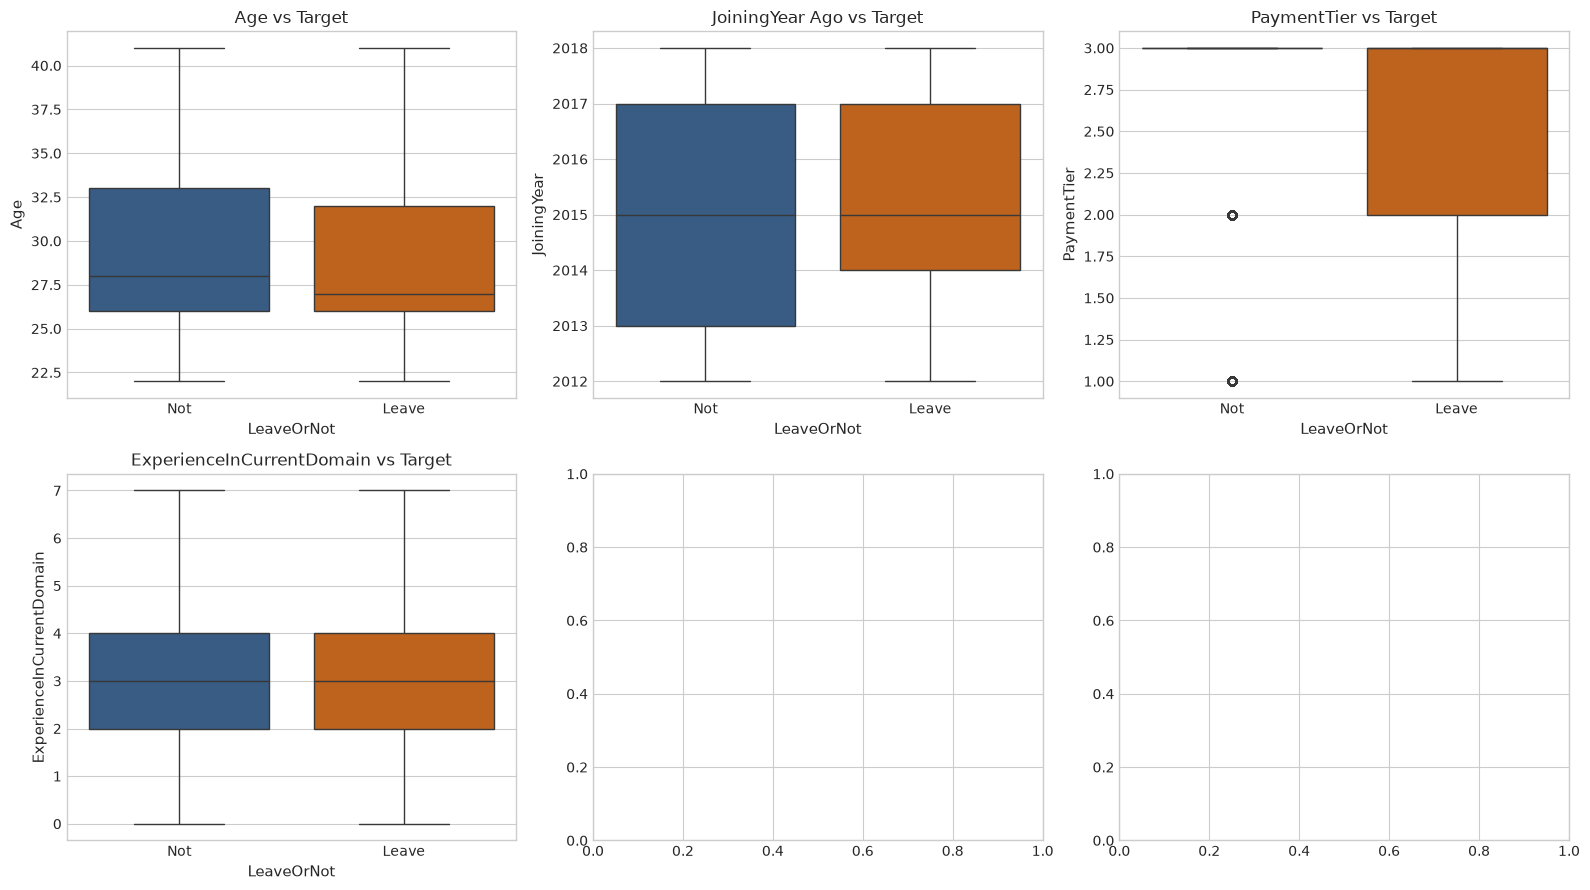

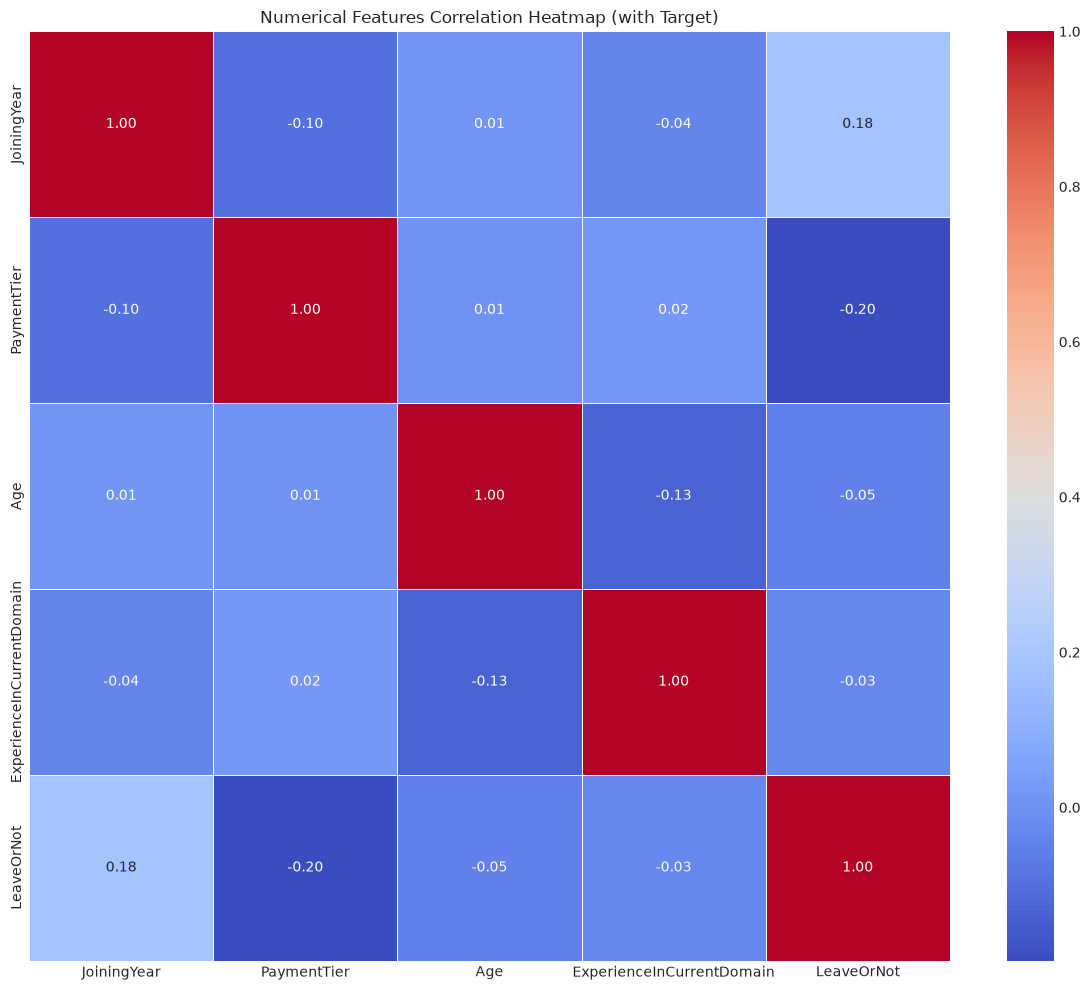

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Categorical vs Churn
sns.countplot(x="Gender", hue=y.map({0: "Not", 1: "Leave"}), data=X_clean, palette=["#2b5c8f", "#d95f02"], ax=axes[0, 0])
axes[0, 0].set_title("Report by Gender")

sns.countplot(x="City", hue=y.map({0: "Not", 1: "Leave"}), data=X_clean, palette=["#2b5c8f", "#d95f02"], ax=axes[0, 1])
axes[0, 1].set_title("Report on City")

sns.countplot(x="Education", hue=y.map({0: "Not", 1: "Leave"}), data=X_clean, palette=["#2b5c8f", "#d95f02"], ax=axes[1, 0])
axes[1, 0].set_title("Report of Education")

sns.countplot(x="EverBenched", hue=y.map({0: "Not", 1: "Leave"}), data=X_clean, palette=["#2b5c8f", "#d95f02"], ax=axes[1, 1])
axes[1, 1].set_title("Report by EverBenched")

plt.tight_layout()
plt.show()

# Key Numerical Boxplots vs Churn
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.boxplot(x=y.map({0: "Not", 1: "Leave"}), y=X_clean["Age"], palette=["#2b5c8f", "#d95f02"], ax=axes[0, 0])
axes[0, 0].set_title("Age vs Target")

sns.boxplot(x=y.map({0: "Not", 1: "Leave"}), y=X_clean["JoiningYear"], palette=["#2b5c8f", "#d95f02"], ax=axes[0, 1])
axes[0, 1].set_title("JoiningYear Ago vs Target")

sns.boxplot(x=y.map({0: "Not", 1: "Leave"}), y=X_clean["PaymentTier"], palette=["#2b5c8f", "#d95f02"], ax=axes[0, 2])
axes[0, 2].set_title("PaymentTier vs Target")

sns.boxplot(x=y.map({0: "Not", 1: "Leave"}), y=X_clean["ExperienceInCurrentDomain"], palette=["#2b5c8f", "#d95f02"], ax=axes[1, 0])
axes[1, 0].set_title("ExperienceInCurrentDomain vs Target")

plt.tight_layout()
plt.show()

# Correlation Matrix Heatmap
plt.figure(figsize=(12, 10))
corr_df = pd.concat([X_clean[numerical_features], y], axis=1).corr()
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Numerical Features Correlation Heatmap (with Target)")
plt.tight_layout()
plt.show()


In [8]:
outlier_summary = []

for col in continuous_numerical_features:
    series = X_clean[col].dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower_b = q1 - 1.5 * iqr
    upper_b = q3 + 1.5 * iqr
    
    outs = series[(series < lower_b) | (series > upper_b)]
    outlier_summary.append({
        "Feature": col,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Lower_Bound": lower_b,
        "Upper_Bound": upper_b,
        "Outlier_Count": len(outs),
        "Outlier_Pct (%)": (len(outs) / len(series)) * 100
    })

outlier_df = pd.DataFrame(outlier_summary)
print("=== IQR OUTLIER AUDIT ===")
display(outlier_df)

print("""
Outlier Handling Rationale:
- Extreme values in customer balances, incomes, and loan amounts represent valid high-value customers.
- We DO NOT delete rows based on statistical outlier boundaries.
- Preprocessing pipelines will handle scaling (StandardScaler/RobustScaler) safely without data leakage.
""")


=== IQR OUTLIER AUDIT ===


,Feature,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Pct (%)
0,JoiningYear,"2,013.0000","2,017.0000",4.0000,"2,007.0000","2,023.0000",0,0.0000
1,PaymentTier,3.0000,3.0000,0.0000,3.0000,3.0000,1161,24.9516
2,Age,26.0000,32.0000,6.0000,17.0000,41.0000,0,0.0000
3,ExperienceInCurrentDomain,2.0000,4.0000,2.0000,-1.0000,7.0000,0,0.0000



Outlier Handling Rationale:
- Extreme values in customer balances, incomes, and loan amounts represent valid high-value customers.
- We DO NOT delete rows based on statistical outlier boundaries.
- Preprocessing pipelines will handle scaling (StandardScaler/RobustScaler) safely without data leakage.



In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_clean,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("=== LEAKAGE-SAFE TRAIN / TEST SPLIT ===")
print(f"X_train Shape: {X_train.shape[0]:,} rows x {X_train.shape[1]} columns")
print(f"X_test  Shape: {X_test.shape[0]:,} rows x {X_test.shape[1]} columns")
print("-" * 50)
print(f"y_train Target Proportion: {y_train.mean()*100:.2f}% ({y_train.sum()} Targeted)")
print(f"y_test  Target Proportion: {y_test.mean()*100:.2f}% ({y_test.sum()} Targeted)")

=== LEAKAGE-SAFE TRAIN / TEST SPLIT ===
X_train Shape: 3,722 rows x 8 columns
X_test  Shape: 931 rows x 8 columns
--------------------------------------------------
y_train Target Proportion: 34.39% (1280 Targeted)
y_test  Target Proportion: 34.37% (320 Targeted)


In [10]:
from sklearn.base import BaseEstimator, TransformerMixin


class EmployeeFeatureEngineer(BaseEstimator, TransformerMixin):

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_out = X.copy()

        # 1. Employee Tenure
        # Approximate years the employee has been in the company
        current_year = 2026
        X_out['Tenure'] = current_year - X_out['JoiningYear']

        # 2. Experience to Age Ratio
        # Shows how much of the employee's age is represented by experience
        X_out['Experience_to_Age_Ratio'] = (
            X_out['ExperienceInCurrentDomain'] /
            (X_out['Age'] + 1.0)
        )

        # 3. Experience Gap
        # Difference between employee age and current-domain experience
        X_out['Experience_Gap'] = (
            X_out['Age'] - X_out['ExperienceInCurrentDomain']
        )

        # 4. Joining Age
        # Approximate age when the employee joined the company
        X_out['Joining_Age'] = (
            X_out['Age'] - X_out['Tenure']
        )

        # 5. Experience per Tenure
        # Relationship between domain experience and company tenure
        X_out['Experience_per_Tenure'] = (
            X_out['ExperienceInCurrentDomain'] /
            (X_out['Tenure'] + 1.0)
        )

        # 6. Early Career Indicator
        # 1 = relatively young employee, 0 = otherwise
        X_out['Early_Career'] = (
            (X_out['Age'] <= 30).astype(int)
        )

        return X_out


# Create feature engineer
fe = EmployeeFeatureEngineer()

# Apply feature engineering
X_train_fe = fe.fit_transform(X_train)


# Engineered columns
engineered_cols = [
    'Tenure',
    'Experience_to_Age_Ratio',
    'Experience_Gap',
    'Joining_Age',
    'Experience_per_Tenure',
    'Early_Career'
]


print("Custom Feature Engineer verified!")
print(f"Engineered Features ({len(engineered_cols)}): {engineered_cols}")

display(X_train_fe[engineered_cols].head(3))

Custom Feature Engineer verified!
Engineered Features (6): ['Tenure', 'Experience_to_Age_Ratio', 'Experience_Gap', 'Joining_Age', 'Experience_per_Tenure', 'Early_Career']


,Tenure,Experience_to_Age_Ratio,Experience_Gap,Joining_Age,Experience_per_Tenure,Early_Career
4097,14,0.0256,37,24,0.0667,0
1694,8,0.1481,22,18,0.4444,1
2659,10,0.1786,22,17,0.4545,1


In [11]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


# Original numerical features
continuous_numerical_features = [
    'JoiningYear',
    'PaymentTier',
    'Age',
    'ExperienceInCurrentDomain'
]

binary_numeric_features = []


# Original categorical features
categorical_features = [
    'Education',
    'City',
    'Gender',
    'EverBenched'
]


# Engineered features
engineered_cols = [
    'Tenure',
    'Experience_to_Age_Ratio',
    'Experience_Gap',
    'Joining_Age',
    'Experience_per_Tenure',
    'Early_Career'
]


# Combine numerical columns
updated_num_cols = (
    continuous_numerical_features
    + binary_numeric_features
    + engineered_cols
)

# Categorical columns remain the same
updated_cat_cols = categorical_features


print(
    f"Total Numerical Columns for Preprocessing "
    f"({len(updated_num_cols)})"
)

print(
    f"Total Categorical Columns for Preprocessing "
    f"({len(updated_cat_cols)})"
)


# Numerical pipeline
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# Categorical pipeline
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])


# Combine numerical + categorical pipelines
preprocessor = ColumnTransformer([
    ("num", num_pipeline, updated_num_cols),
    ("cat", cat_pipeline, updated_cat_cols)
])


# Complete pipeline
full_prep_pipeline = Pipeline([
    ("feature_engineering", EmployeeFeatureEngineer()),
    ("preprocessor", preprocessor)
])


# Fit only on training data
X_train_proc = full_prep_pipeline.fit_transform(X_train)


print(
    f"Preprocessed Feature Matrix Shape: "
    f"{X_train_proc.shape}"
)

Total Numerical Columns for Preprocessing (10)
Total Categorical Columns for Preprocessing (4)
Preprocessed Feature Matrix Shape: (3722, 20)


In [12]:
baseline_models = {
    "Logistic Regression": LogisticRegression(class_weight="balanced", random_state=RANDOM_STATE, max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=7),
    "Decision Tree": DecisionTreeClassifier(class_weight="balanced", max_depth=6, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(class_weight="balanced", n_estimators=100, random_state=RANDOM_STATE),
    "Extra Trees": ExtraTreesClassifier(class_weight="balanced", n_estimators=100, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=RANDOM_STATE),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
    "Support Vector Classifier": SVC(class_weight="balanced", probability=True, random_state=RANDOM_STATE),
    "Gaussian Naive Bayes": GaussianNB()
}

cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
baseline_results = []

for name, clf in baseline_models.items():
    pipe = Pipeline([
        ("feature_engineering", EmployeeFeatureEngineer()),
        ("preprocessor", preprocessor),
        ("classifier", clf)
    ])
    
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=cv_strat, scoring="f1", n_jobs=-1)
    
    pipe.fit(X_train, y_train)
    y_test_pred = pipe.predict(X_test)
    y_test_proba = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, "predict_proba") else pipe.decision_function(X_test)
    y_train_pred = pipe.predict(X_train)
    
    train_f1 = f1_score(y_train, y_train_pred, zero_division=0)
    acc = accuracy_score(y_test, y_test_pred)
    prec = precision_score(y_test, y_test_pred, zero_division=0)
    rec = recall_score(y_test, y_test_pred, zero_division=0)
    f1 = f1_score(y_test, y_test_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_test_proba)
    pr = average_precision_score(y_test, y_test_proba)
    
    baseline_results.append({
        "Model": name,
        "CV F1 (Mean)": cv_scores.mean(),
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": roc,
        "PR-AUC": pr,
        "Train F1": train_f1,
        "Train-Test Gap": train_f1 - f1
    })

baseline_df = pd.DataFrame(baseline_results).sort_values(by="F1-Score", ascending=False)
print("=== BASELINE MODELS COMPARISON ===")
display(baseline_df)


=== BASELINE MODELS COMPARISON ===


,Model,CV F1 (Mean),Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Train F1,Train-Test Gap
2,Decision Tree,0.7439,0.8518,0.8273,0.7188,0.7692,0.8717,0.8269,0.7642,-0.0050
5,Gradient Boosting,0.7316,0.8528,0.8765,0.6656,0.7567,0.8847,0.8585,0.7629,0.0062
7,Support Vector Classifier,0.7284,0.8292,0.7605,0.7344,0.7472,0.8438,0.8099,0.7569,0.0097
6,HistGradientBoosting,0.7377,0.8432,0.8655,0.6438,0.7384,0.8857,0.8579,0.8292,0.0909
3,Random Forest,0.7053,0.8249,0.7875,0.6719,0.7251,0.8550,0.8219,0.8942,0.1691
4,Extra Trees,0.6987,0.8153,0.7606,0.6750,0.7152,0.8275,0.7518,0.8954,0.1802
1,K-Nearest Neighbors,0.6757,0.7970,0.7964,0.5500,0.6506,0.8240,0.7470,0.7534,0.1027
0,Logistic Regression,0.6024,0.7121,0.5670,0.6875,0.6215,0.7389,0.5868,0.6049,-0.0165
8,Gaussian Naive Bayes,0.5713,0.6992,0.5578,0.6031,0.5796,0.7181,0.5484,0.5751,-0.0045


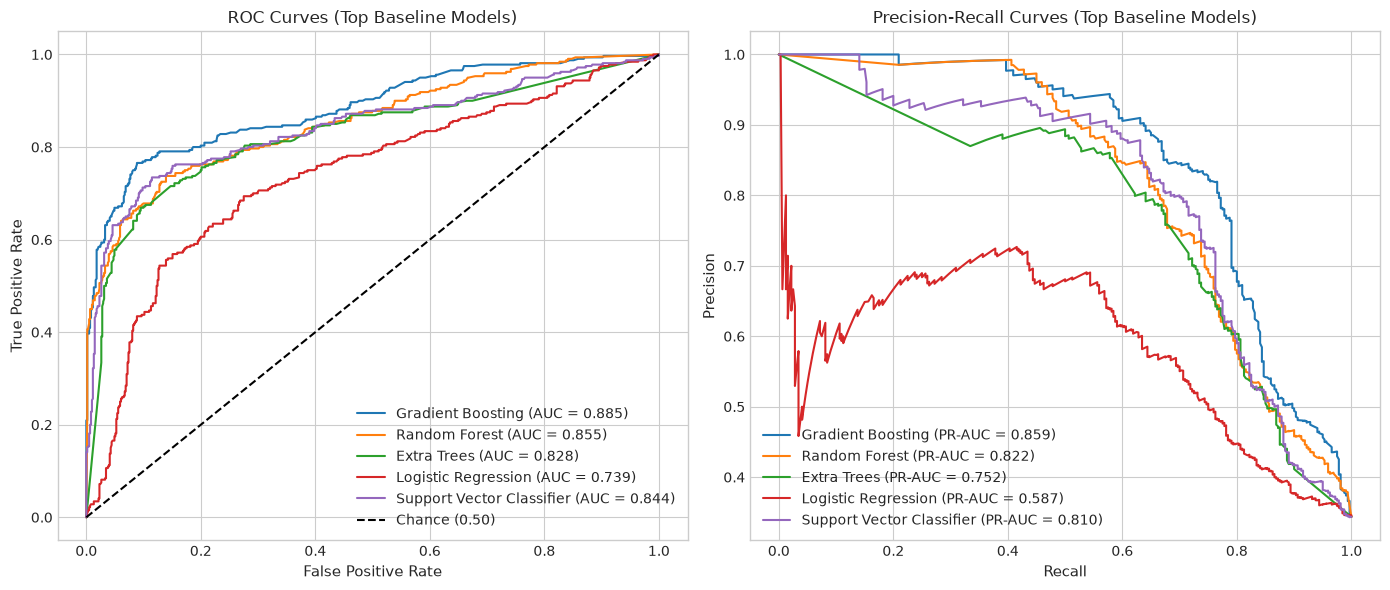

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

top_names = ["Gradient Boosting", "Random Forest", "Extra Trees", "Logistic Regression", "Support Vector Classifier"]

for name in top_names:
    clf = baseline_models[name]
    pipe = Pipeline([
        ("feature_engineering", EmployeeFeatureEngineer()),
        ("preprocessor", preprocessor),
        ("classifier", clf)
    ])
    pipe.fit(X_train, y_train)
    y_proba = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, "predict_proba") else pipe.decision_function(X_test)
    
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc_val = roc_auc_score(y_test, y_proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC = {auc_val:.3f})")
    
    p_vals, r_vals, _ = precision_recall_curve(y_test, y_proba)
    pr_auc_val = average_precision_score(y_test, y_proba)
    axes[1].plot(r_vals, p_vals, label=f"{name} (PR-AUC = {pr_auc_val:.3f})")

axes[0].plot([0, 1], [0, 1], "k--", label="Chance (0.50)")
axes[0].set_title("ROC Curves (Top Baseline Models)")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].legend(loc="lower right")

axes[1].set_title("Precision-Recall Curves (Top Baseline Models)")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].legend(loc="lower left")

plt.tight_layout()
plt.show()


In [14]:
# 1. Tune Gradient Boosting
gb_pipe = Pipeline([
    ("feature_engineering", EmployeeFeatureEngineer()),
    ("preprocessor", preprocessor),
    ("classifier", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

gb_grid = {
    "classifier__n_estimators": [100, 150, 200],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
    "classifier__max_depth": [3, 4, 5],
    "classifier__subsample": [0.8, 0.9, 1.0]
}

gb_search = GridSearchCV(gb_pipe, param_grid=gb_grid, scoring="f1", cv=cv_strat, n_jobs=-1)
gb_search.fit(X_train, y_train)

print(f"Best Gradient Boosting CV F1 Score: {gb_search.best_score_:.4f}")
print("Best Gradient Boosting Parameters:")
print(gb_search.best_params_)

# 2. Tune Random Forest
rf_pipe = Pipeline([
    ("feature_engineering", EmployeeFeatureEngineer()),
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE))
])

rf_grid = {
    "classifier__n_estimators": [150, 200],
    "classifier__max_depth": [8, 10, 12],
    "classifier__min_samples_leaf": [2, 4, 6]
}

rf_search = GridSearchCV(rf_pipe, param_grid=rf_grid, scoring="f1", cv=cv_strat, n_jobs=-1)
rf_search.fit(X_train, y_train)

print(f"\nBest Random Forest CV F1 Score: {rf_search.best_score_:.4f}")
print("Best Random Forest Parameters:")
print(rf_search.best_params_)


Best Gradient Boosting CV F1 Score: 0.7528
Best Gradient Boosting Parameters:
{'classifier__learning_rate': 0.03, 'classifier__max_depth': 5, 'classifier__n_estimators': 150, 'classifier__subsample': 0.9}

Best Random Forest CV F1 Score: 0.7526
Best Random Forest Parameters:
{'classifier__max_depth': 12, 'classifier__min_samples_leaf': 4, 'classifier__n_estimators': 200}


In [15]:
best_gb_clf = gb_search.best_estimator_.named_steps["classifier"]
best_rf_clf = rf_search.best_estimator_.named_steps["classifier"]

tuned_et_clf = ExtraTreesClassifier(n_estimators=200, max_depth=12, min_samples_leaf=3, class_weight="balanced", random_state=RANDOM_STATE)
tuned_lr_clf = LogisticRegression(C=0.5, class_weight="balanced", random_state=RANDOM_STATE, max_iter=1000)

# Soft Voting Ensemble
voting_clf = VotingClassifier(
    estimators=[
        ("gb", best_gb_clf),
        ("rf", best_rf_clf),
        ("et", tuned_et_clf),
        ("lr", tuned_lr_clf)
    ],
    voting="soft"
)

voting_pipe = Pipeline([
    ("feature_engineering", EmployeeFeatureEngineer()),
    ("preprocessor", preprocessor),
    ("classifier", voting_clf)
])

# Stacking Ensemble
stacking_clf = StackingClassifier(
    estimators=[
        ("gb", best_gb_clf),
        ("rf", best_rf_clf),
        ("et", tuned_et_clf)
    ],
    final_estimator=LogisticRegression(C=1.0, random_state=RANDOM_STATE),
    cv=cv_strat
)

stacking_pipe = Pipeline([
    ("feature_engineering", EmployeeFeatureEngineer()),
    ("preprocessor", preprocessor),
    ("classifier", stacking_clf)
])

voting_pipe.fit(X_train, y_train)
stacking_pipe.fit(X_train, y_train)

print("Soft Voting Ensemble and Stacking Ensemble successfully trained!")


Soft Voting Ensemble and Stacking Ensemble successfully trained!


In [16]:
candidate_pipes = {
    "Tuned Gradient Boosting": gb_search.best_estimator_,
    "Tuned Random Forest": rf_search.best_estimator_,
    "Tuned Extra Trees": Pipeline([("fe", EmployeeFeatureEngineer()), ("prep", preprocessor), ("clf", tuned_et_clf)]),
    "Tuned Logistic Regression": Pipeline([("fe", EmployeeFeatureEngineer()), ("prep", preprocessor), ("clf", tuned_lr_clf)]),
    "Soft Voting Ensemble": voting_pipe,
    "Stacking Ensemble": stacking_pipe
}

final_metrics = []

for name, p in candidate_pipes.items():
    if name not in ["Tuned Gradient Boosting", "Tuned Random Forest", "Soft Voting Ensemble", "Stacking Ensemble"]:
        p.fit(X_train, y_train)
        
    y_pred = p.predict(X_test)
    y_prob = p.predict_proba(X_test)[:, 1]
    
    y_tr_pred = p.predict(X_train)
    tr_f1 = f1_score(y_train, y_tr_pred, zero_division=0)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc = roc_auc_score(y_test, y_prob)
    pr = average_precision_score(y_test, y_prob)
    
    final_metrics.append({
        "Model": name,
        "Accuracy": acc,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "ROC-AUC": roc,
        "PR-AUC": pr,
        "Train F1": tr_f1,
        "Train-Test Gap": tr_f1 - f1
    })

final_df = pd.DataFrame(final_metrics).sort_values(by="F1-Score", ascending=False)
print("=== FINAL MODEL COMPARISON ===")
display(final_df)


=== FINAL MODEL COMPARISON ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,PR-AUC,Train F1,Train-Test Gap
2,Tuned Extra Trees,0.8700,0.8541,0.7500,0.7987,0.8778,0.8550,0.8199,0.0213
4,Soft Voting Ensemble,0.8679,0.8481,0.7500,0.7960,0.8769,0.8563,0.8075,0.0114
1,Tuned Random Forest,0.8625,0.8453,0.7344,0.7860,0.8875,0.8631,0.8150,0.0290
5,Stacking Ensemble,0.8657,0.8916,0.6937,0.7803,0.8876,0.8646,0.7995,0.0192
0,Tuned Gradient Boosting,0.8636,0.8971,0.6813,0.7744,0.8886,0.8631,0.7923,0.0179
3,Tuned Logistic Regression,0.7175,0.5740,0.6906,0.6270,0.7391,0.5861,0.6069,-0.0200


In [17]:
final_production_pipeline = voting_pipe

print("=== FINAL SELECTED PIPELINE (Soft Voting Ensemble) ===")
print(final_production_pipeline)


=== FINAL SELECTED PIPELINE (Soft Voting Ensemble) ===
Pipeline(steps=[('feature_engineering', EmployeeFeatureEngineer()),
                ('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['JoiningYear', 'PaymentTier',
                                                   'Age',
                                                   'ExperienceInCurrentDomain',
                                                   'Tenure',
                                                   'Experience_to_Age_Ratio',
                                                   'Experience_Gap',
               

Optimal F1 Decision Threshold: 0.50 (F1-Score = 0.7960)


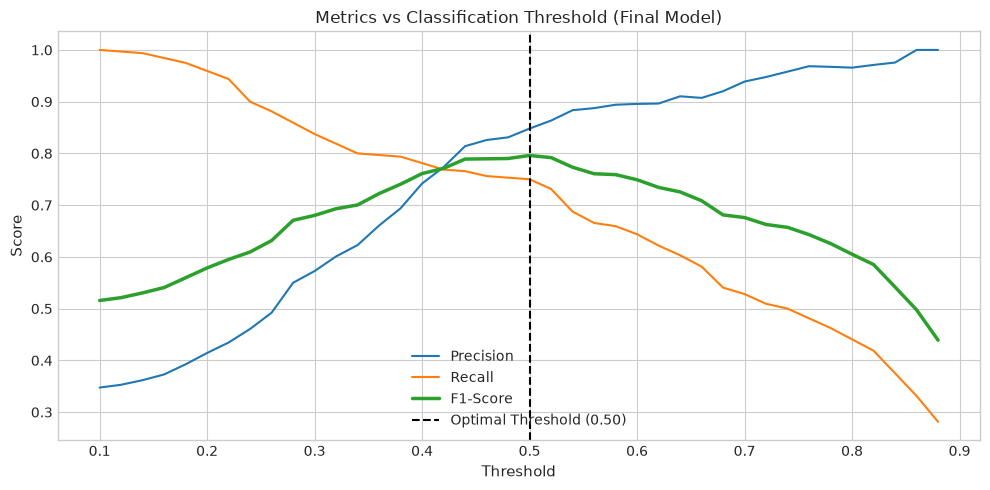

In [18]:
y_test_proba = final_production_pipeline.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.02)
thresh_records = []

for t in thresholds:
    y_pred_t = (y_test_proba >= t).astype(int)
    prec = precision_score(y_test, y_pred_t, zero_division=0)
    rec = recall_score(y_test, y_pred_t, zero_division=0)
    f1 = f1_score(y_test, y_pred_t, zero_division=0)
    acc = accuracy_score(y_test, y_pred_t)
    
    thresh_records.append({
        "Threshold": t,
        "Precision": prec,
        "Recall": rec,
        "F1-Score": f1,
        "Accuracy": acc
    })

thresh_df = pd.DataFrame(thresh_records)

best_idx = thresh_df["F1-Score"].idxmax()
best_threshold = thresh_df.loc[best_idx, "Threshold"]
best_f1 = thresh_df.loc[best_idx, "F1-Score"]

print(f"Optimal F1 Decision Threshold: {best_threshold:.2f} (F1-Score = {best_f1:.4f})")

plt.figure(figsize=(10, 5))
plt.plot(thresh_df["Threshold"], thresh_df["Precision"], label="Precision", color="#1f77b4")
plt.plot(thresh_df["Threshold"], thresh_df["Recall"], label="Recall", color="#ff7f0e")
plt.plot(thresh_df["Threshold"], thresh_df["F1-Score"], label="F1-Score", color="#2ca02c", linewidth=2.5)
plt.axvline(x=best_threshold, color="black", linestyle="--", label=f"Optimal Threshold ({best_threshold:.2f})")

plt.title("Metrics vs Classification Threshold (Final Model)")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.tight_layout()
plt.show()


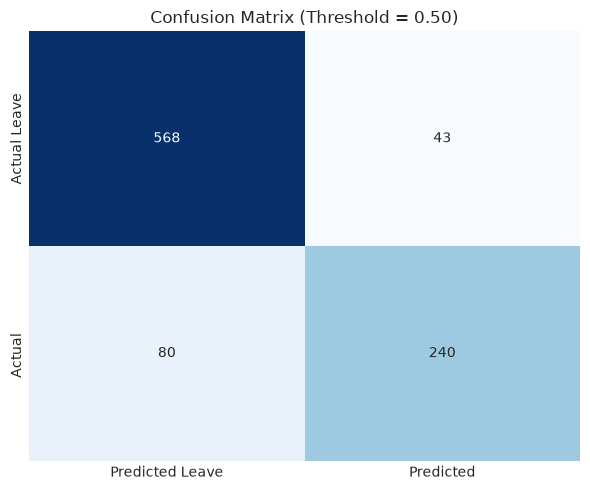

=== FINAL CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

Retained (0)       0.88      0.93      0.90       611
 Churned (1)       0.85      0.75      0.80       320

    accuracy                           0.87       931
   macro avg       0.86      0.84      0.85       931
weighted avg       0.87      0.87      0.87       931



In [19]:
OPTIMAL_THRESHOLD = best_threshold
y_test_pred_opt = (y_test_proba >= OPTIMAL_THRESHOLD).astype(int)

cm = confusion_matrix(y_test, y_test_pred_opt)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
            xticklabels=["Predicted Leave", "Predicted"],
            yticklabels=["Actual Leave", "Actual "])
ax.set_title(f"Confusion Matrix (Threshold = {OPTIMAL_THRESHOLD:.2f})")
plt.tight_layout()
plt.show()

print("=== FINAL CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_test_pred_opt, target_names=["Retained (0)", "Churned (1)"]))


=== TOP 15 MOST IMPORTANT FEATURES ===


,Feature,Importance
1,PaymentTier,0.2129
0,JoiningYear,0.2002
4,Tenure,0.1675
15,City_Pune,0.0972
11,Education_Masters,0.0669
10,Education_Bachelors,0.0507
7,Joining_Age,0.0287
8,Experience_per_Tenure,0.0257
5,Experience_to_Age_Ratio,0.0250
13,City_Bangalore,0.0231


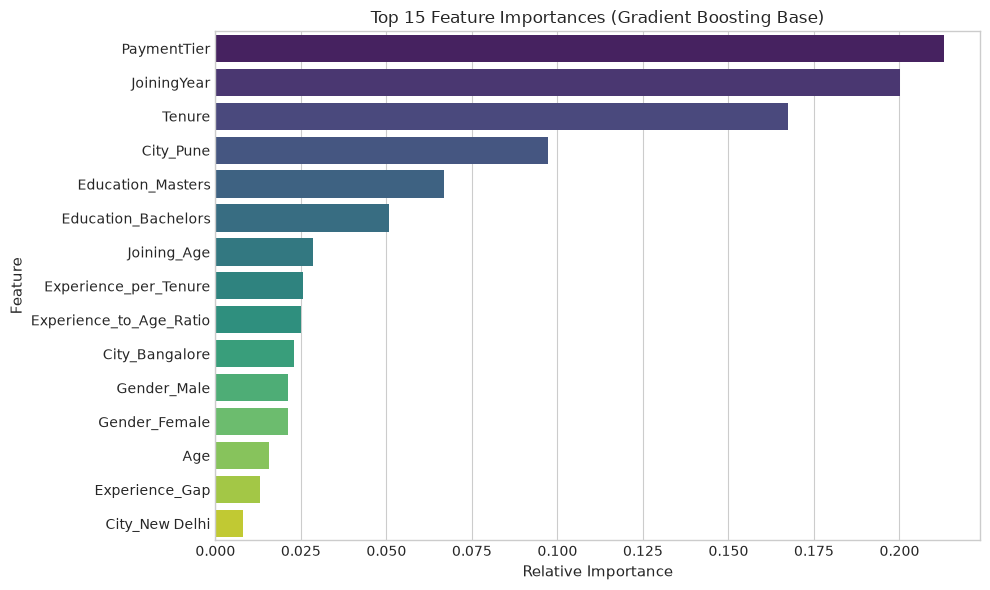

In [20]:
gb_fitted = final_production_pipeline.named_steps["classifier"].named_estimators_["gb"]

ohe = full_prep_pipeline.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
cat_encoded_names = ohe.get_feature_names_out(updated_cat_cols).tolist()
all_transformed_names = updated_num_cols + cat_encoded_names

importances = gb_fitted.feature_importances_
feat_imp_df = pd.DataFrame({
    "Feature": all_transformed_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print("=== TOP 15 MOST IMPORTANT FEATURES ===")
display(feat_imp_df.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Feature", data=feat_imp_df.head(15), palette="viridis")
plt.title("Top 15 Feature Importances (Gradient Boosting Base)")
plt.xlabel("Relative Importance")
plt.tight_layout()
plt.show()


In [21]:
new_employee_raw = pd.DataFrame([{
    "JoiningYear": 2018,
    "PaymentTier": 2,
    "Age": 32,
    "ExperienceInCurrentDomain": 4,
    "Education": "Bachelors",
    "City": "Bangalore",
    "Gender": "Male",
    "EverBenched": "No"
}])


print("Raw Sample Employee Input:")
display(new_employee_raw)


# Get probability of LeaveOrNot = 1
prob_leave = final_production_pipeline.predict_proba(new_employee_raw)[0, 1]

# Probability of LeaveOrNot = 0
prob_stay = 1.0 - prob_leave

# Apply optimal threshold
pred_class = int(prob_leave >= OPTIMAL_THRESHOLD)


print("\n=== REAL-TIME INFERENCE RESULT ===")
print(f"Leave Probability        : {prob_leave * 100:.2f}%")
print(f"Stay Probability         : {prob_stay * 100:.2f}%")
print(f"Optimal Decision Cutoff  : {OPTIMAL_THRESHOLD:.2f}")
print(
    f"Predicted Status         : "
    f"{'LEAVE (1)' if pred_class == 1 else 'STAY (0)'}"
)

Raw Sample Employee Input:


,JoiningYear,PaymentTier,Age,ExperienceInCurrentDomain,Education,City,Gender,EverBenched
0,2018,2,32,4,Bachelors,Bangalore,Male,No



=== REAL-TIME INFERENCE RESULT ===
Leave Probability        : 80.50%
Stay Probability         : 19.50%
Optimal Decision Cutoff  : 0.50
Predicted Status         : LEAVE (1)


In [22]:
prob_leave

np.float64(0.8049938020347337)

In [23]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [24]:
final_production_pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('feature_engineering', ...), ('preprocessor', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the differ

In [25]:
gb_fitted

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.03
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",150
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",0.9
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",5
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``,

In [26]:
ohe

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_cate

In [27]:
importances

array([0.20021305, 0.21289261, 0.01581051, 0.00435117, 0.16752448,
       0.02498449, 0.01294587, 0.02867969, 0.02567609, 0.00024366,
       0.05065497, 0.06688313, 0.00434947, 0.02307898, 0.0081711 ,
       0.09717621, 0.02113409, 0.02132   , 0.00770703, 0.00620341])

In [28]:

import joblib

In [29]:
import os

print(os.path.exists("final_employee_churn_pipeline.pkl"))

True


In [30]:
print(os.path.getsize("final_employee_churn_pipeline.pkl"), "bytes")

34299588 bytes


In [31]:
prob_leave = final_production_pipeline.predict_proba(new_employee_raw)[0, 1]

prob_stay = 1 - prob_leave

pred_class = int(prob_leave >= OPTIMAL_THRESHOLD)

print("=== SAVED MODEL TEST ===")
print(f"Leave Probability : {prob_leave * 100:.2f}%")
print(f"Stay Probability  : {prob_stay * 100:.2f}%")
print(f"Prediction        : {'LEAVE (1)' if pred_class == 1 else 'STAY (0)'}")

=== SAVED MODEL TEST ===
Leave Probability : 80.50%
Stay Probability  : 19.50%
Prediction        : LEAVE (1)


In [32]:
joblib.dump(final_production_pipeline,
            "final_employee_churn_pipeline1.pkl")

['final_employee_churn_pipeline1.pkl']

In [33]:
import sklearn
print(sklearn.__version__)

1.8.0
